GHG Emissions Intensity Modeling

**Problem statement:** Can building characteristics and fuel-use mix predict **Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)** in NYC benchmarked buildings?

## Objective
- Build a clean starter regression workflow for GHG emissions intensity.
- Use building characteristics plus observed fuel-use mix.
- Compare simple baselines against a stronger tree model.


In [2]:
from __future__ import annotations

import re
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

DATA_PATH = Path("NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv")
TARGET = "Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)"
CURRENT_YEAR = 2026
TARGET_UPPER_QUANTILE = 0.99

BUILDING_NUMERIC_COLUMNS = [
    "Calendar Year",
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Number of Buildings",
    "Occupancy",
]

BUILDING_CATEGORICAL_COLUMNS = [
    "Primary Property Type - Self Selected",
    "Largest Property Use Type",
    "City",
]

FUEL_USE_COLUMNS = [
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "District Chilled Water Use (kBtu)",
    "Fuel Oil #1 Use (kBtu)",
    "Fuel Oil #2 Use (kBtu)",
    "Fuel Oil #4 Use (kBtu)",
    "Fuel Oil #5 & 6 Use (kBtu)",
    "Diesel #2 Use (kBtu)",
    "Propane Use (kBtu)",
    "Kerosene Use (kBtu)",
]


## Data loading and cleaning helpers

These helpers keep the workflow reproducible and make it easier to tighten cleaning rules later.


In [4]:
def make_feature_slug(name: str) -> str:
    slug = name.lower()
    slug = slug.replace("(kbtu)", "")
    slug = slug.replace("(ft²)", "")
    slug = slug.replace("use", "")
    slug = slug.replace(" - ", "_")
    slug = re.sub(r"[^a-z0-9]+", "_", slug)
    return slug.strip("_")


def to_numeric(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(",", "", regex=False)
    cleaned = cleaned.replace({"Not Available": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")


def load_shared_dataset(data_path: Path) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(
            f"Missing required input file: {data_path}. "
            "Run Shared_EDA.ipynb first to export the shared-cleaned CSV."
        )

    raw_df = pd.read_csv(data_path, low_memory=False)
    if TARGET not in raw_df.columns:
        raise KeyError(f"Required target column not found: {TARGET}")

    requested_columns = [TARGET] + BUILDING_NUMERIC_COLUMNS + BUILDING_CATEGORICAL_COLUMNS + FUEL_USE_COLUMNS
    available_columns = [col for col in requested_columns if col in raw_df.columns]
    missing_columns = [col for col in requested_columns if col not in raw_df.columns]

    if missing_columns:
        print("Missing columns skipped:")
        for col in missing_columns:
            print("-", col)
        print()

    df = raw_df[available_columns].copy()

    numeric_columns = [col for col in [TARGET] + BUILDING_NUMERIC_COLUMNS + FUEL_USE_COLUMNS if col in df.columns]
    for col in numeric_columns:
        df[col] = to_numeric(df[col])

    return df


def clean_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    if "Year Built" in cleaned.columns:
        cleaned.loc[(cleaned["Year Built"] < 1800) | (cleaned["Year Built"] > CURRENT_YEAR), "Year Built"] = np.nan

    if "Occupancy" in cleaned.columns:
        cleaned.loc[(cleaned["Occupancy"] < 0) | (cleaned["Occupancy"] > 100), "Occupancy"] = np.nan

    if "Number of Buildings" in cleaned.columns:
        cleaned.loc[cleaned["Number of Buildings"] <= 0, "Number of Buildings"] = np.nan

    for col in [
        "Property GFA - Self-Reported (ft²)",
        "Largest Property Use Type - Gross Floor Area (ft²)",
    ]:
        if col in cleaned.columns:
            cleaned.loc[cleaned[col] <= 0, col] = np.nan

    for col in [fuel_col for fuel_col in FUEL_USE_COLUMNS if fuel_col in cleaned.columns]:
        cleaned.loc[cleaned[col] < 0, col] = np.nan

    cleaned.loc[cleaned[TARGET] <= 0, TARGET] = np.nan
    return cleaned


## Feature engineering

The first-pass feature set mixes:
- building metadata
- size proxies
- total fuel use
- fuel-use intensity
- fuel-share features
- missingness indicators for each fuel source


In [6]:
def engineer_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    model_df = df.copy()
    fuel_columns = [col for col in FUEL_USE_COLUMNS if col in model_df.columns]
    if not fuel_columns:
        raise ValueError("No fuel-use columns were found, so the fuel-mix model cannot be built.")

    model_df["Model GFA (ft²)"] = model_df["Property GFA - Self-Reported (ft²)"]
    if "Largest Property Use Type - Gross Floor Area (ft²)" in model_df.columns:
        model_df["Model GFA (ft²)"] = model_df["Model GFA (ft²)"].fillna(
            model_df["Largest Property Use Type - Gross Floor Area (ft²)"]
        )

    model_df.loc[model_df["Model GFA (ft²)"] <= 0, "Model GFA (ft²)"] = np.nan

    if "Largest Property Use Type - Gross Floor Area (ft²)" in model_df.columns:
        model_df["Largest Use Share of GFA"] = (
            model_df["Largest Property Use Type - Gross Floor Area (ft²)"] / model_df["Model GFA (ft²)"]
        )
    else:
        model_df["Largest Use Share of GFA"] = np.nan

    missing_flag_features = []
    share_features = []

    for col in fuel_columns:
        feature_prefix = make_feature_slug(col)
        missing_flag = f"{feature_prefix}_missing"
        share_feature = f"{feature_prefix}_share"

        model_df[missing_flag] = model_df[col].isna().astype(int)
        missing_flag_features.append(missing_flag)

        model_df[col] = model_df[col].fillna(0.0)
        share_features.append(share_feature)

    model_df["Total Fuel Use (kBtu)"] = model_df[fuel_columns].sum(axis=1)
    model_df.loc[model_df["Total Fuel Use (kBtu)"] <= 0, "Total Fuel Use (kBtu)"] = np.nan

    model_df["Fuel Use Intensity (kBtu/ft²)"] = model_df["Total Fuel Use (kBtu)"] / model_df["Model GFA (ft²)"]
    model_df["Log Model GFA"] = np.log1p(model_df["Model GFA (ft²)"])
    model_df["Log Total Fuel Use"] = np.log1p(model_df["Total Fuel Use (kBtu)"])

    for col in fuel_columns:
        share_feature = f"{make_feature_slug(col)}_share"
        model_df[share_feature] = model_df[col] / model_df["Total Fuel Use (kBtu)"]
        model_df[share_feature] = model_df[share_feature].fillna(0.0)

    numeric_features = [
        "Calendar Year",
        "Year Built",
        "Number of Buildings",
        "Occupancy",
        "Model GFA (ft²)",
        "Largest Use Share of GFA",
        "Fuel Use Intensity (kBtu/ft²)",
        "Log Model GFA",
        "Log Total Fuel Use",
    ]
    numeric_features = [col for col in numeric_features if col in model_df.columns]
    numeric_features.extend(share_features)
    numeric_features.extend(missing_flag_features)

    categorical_features = [col for col in BUILDING_CATEGORICAL_COLUMNS if col in model_df.columns]
    return model_df, numeric_features, categorical_features


def build_model_subset(df: pd.DataFrame) -> pd.DataFrame:
    subset = df.dropna(subset=[TARGET, "Total Fuel Use (kBtu)", "Fuel Use Intensity (kBtu/ft²)"]).copy()
    if subset.empty:
        raise ValueError("No rows remain after the initial target and fuel-use filters.")

    target_upper = subset[TARGET].quantile(TARGET_UPPER_QUANTILE)
    subset = subset[subset[TARGET] <= target_upper].copy()
    if subset.empty:
        raise ValueError("No rows remain after trimming extreme target outliers.")

    return subset


def print_dataset_snapshot(df: pd.DataFrame, model_df: pd.DataFrame) -> None:
    print("Initial rows:", len(df))
    print("Modeling rows after cleaning and filtering:", len(model_df))
    print()
    print("Target summary:")
    print(model_df[TARGET].describe())
    print()


def plot_target_distribution(model_df: pd.DataFrame) -> None:
    plt.figure(figsize=(7, 4.5))
    sns.histplot(model_df[TARGET], bins=40, color="steelblue")
    plt.title("Distribution of Total Location-Based GHG Emissions Intensity")
    plt.xlabel(TARGET)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 2.5))
    sns.boxplot(x=model_df[TARGET], color="steelblue")
    plt.title("Boxplot of Total Location-Based GHG Emissions Intensity")
    plt.xlabel(TARGET)
    plt.tight_layout()
    plt.show()


## Modeling helpers

The notebook compares a few baseline regressors first, then runs a compact random-forest search.


In [8]:
def build_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])


def evaluate_models(X_train, X_test, y_train, y_test, preprocessor):
    models = {
        "DummyRegressor": DummyRegressor(strategy="mean"),
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42,
        ),
    }

    results = []
    fitted_pipelines = {}
    predictions = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
        })

        fitted_pipelines[name] = pipeline
        predictions[name] = y_pred

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    return results_df, fitted_pipelines, predictions


def tune_random_forest(X_train, y_train, preprocessor):
    tuning_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ])

    param_distributions = {
        "model__n_estimators": [200, 300, 400],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", 0.8],
    }

    search = RandomizedSearchCV(
        estimator=tuning_pipeline,
        param_distributions=param_distributions,
        n_iter=8,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    return search


def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.08, s=8)

    lower = min(float(y_true.min()), float(np.min(y_pred)))
    upper = max(float(y_true.max()), float(np.max(y_pred)))
    plt.plot([lower, upper], [lower, upper], color="red", linewidth=2, linestyle="--")

    plt.xlabel(f"Actual {TARGET}")
    plt.ylabel(f"Predicted {TARGET}")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def summarize_feature_importance(fitted_pipeline, top_n=20):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_,
    }).sort_values("Importance", ascending=False)

    top_features = importance_df.head(top_n).reset_index(drop=True)
    display(top_features)

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=top_features.sort_values("Importance", ascending=True),
        x="Importance",
        y="Feature",
        color="steelblue",
    )
    plt.title("Top Feature Importances: Tuned Random Forest")
    plt.tight_layout()
    plt.show()

    return importance_df


## Load and prepare the modeling dataset


In [10]:
df = load_shared_dataset(DATA_PATH)
df = clean_anomalies(df)
df, numeric_features, categorical_features = engineer_features(df)
model_df = build_model_subset(df)

print_dataset_snapshot(df, model_df)
print("Numeric features:")
for col in numeric_features:
    print("-", col)
print()

print("Categorical features:")
for col in categorical_features:
    print("-", col)


Initial rows: 103259
Modeling rows after cleaning and filtering: 89004

Target summary:
count    89004.000000
mean         5.433071
std          3.219727
min          0.010000
25%          3.800000
50%          4.900000
75%          6.370000
max         29.300000
Name: Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²), dtype: float64

Numeric features:
- Calendar Year
- Year Built
- Number of Buildings
- Occupancy
- Model GFA (ft²)
- Largest Use Share of GFA
- Fuel Use Intensity (kBtu/ft²)
- Log Model GFA
- Log Total Fuel Use
- electricity_grid_purchase_share
- natural_gas_share
- district_steam_share
- district_hot_water_share
- district_chilled_water_share
- fuel_oil_1_share
- fuel_oil_2_share
- fuel_oil_4_share
- fuel_oil_5_6_share
- diesel_2_share
- propane_share
- kerosene_share
- electricity_grid_purchase_missing
- natural_gas_missing
- district_steam_missing
- district_hot_water_missing
- district_chilled_water_missing
- fuel_oil_1_missing
- fuel_oil_2_missing
- fuel_o

/var/folders/4f/6jnm_f3j7nj7w5jj9_61s9y40000gn/T/ipykernel_69314/181112843.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = cleaned.replace({"Not Available": np.nan, "nan": np.nan, "None": np.nan})


## Target distribution

Use these plots to check skew, spread, and whether additional target transforms are worth testing later.


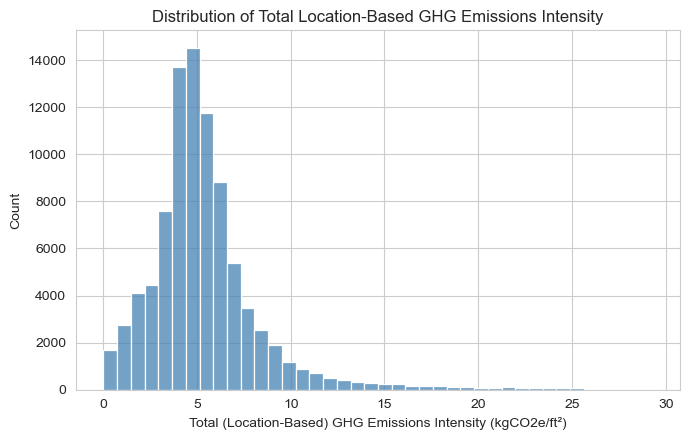

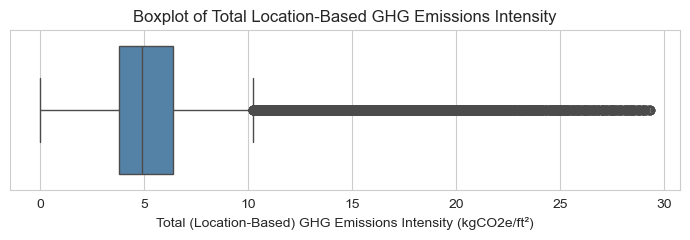

In [12]:
plot_target_distribution(model_df)


## Train/test split and baseline models


In [14]:
feature_columns = numeric_features + categorical_features
X = model_df[feature_columns].copy()
y = model_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

preprocessor = build_preprocessor(numeric_features, categorical_features)
results_df, fitted_pipelines, predictions = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor,
)

results_df


,Model,MAE,RMSE,R2
0,RandomForestRegressor,0.083716,0.296393,9.914741e-01
1,Ridge,0.366692,0.683873,9.546107e-01
2,LinearRegression,0.367150,0.684866,9.544788e-01
3,DummyRegressor,2.082982,3.209954,-9.024904e-08


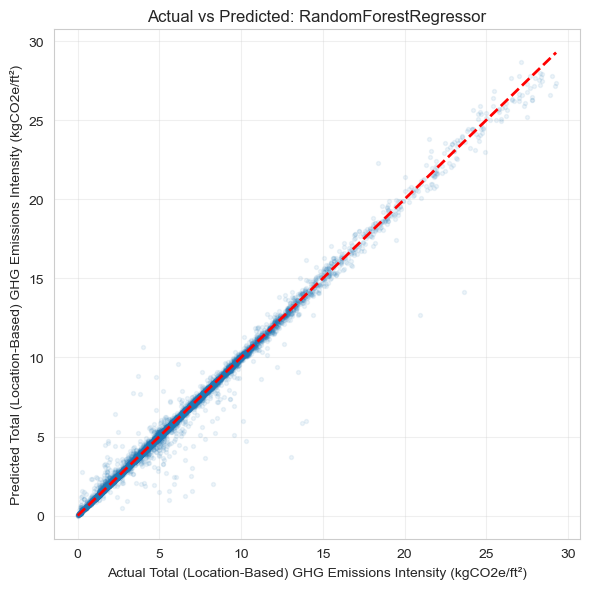

In [15]:
best_baseline_name = results_df.loc[0, "Model"]
plot_actual_vs_predicted(
    y_test,
    predictions[best_baseline_name],
    title=f"Actual vs Predicted: {best_baseline_name}",
)


## Random-forest tuning and feature importance


In [17]:
random_search = tune_random_forest(X_train, y_train, preprocessor)
tuned_pipeline = random_search.best_estimator_
tuned_predictions = tuned_pipeline.predict(X_test)

tuned_results = pd.DataFrame([
    {
        "Model": "TunedRandomForest",
        "MAE": mean_absolute_error(y_test, tuned_predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, tuned_predictions)),
        "R2": r2_score(y_test, tuned_predictions),
    }
])

comparison_df = pd.concat([results_df, tuned_results], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
print("Best RF parameters:")
print(random_search.best_params_)
print()
comparison_df


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__max_depth': 20}



,Model,MAE,RMSE,R2
0,TunedRandomForest,0.087652,0.294091,9.916061e-01
1,RandomForestRegressor,0.083716,0.296393,9.914741e-01
2,Ridge,0.366692,0.683873,9.546107e-01
3,LinearRegression,0.367150,0.684866,9.544788e-01
4,DummyRegressor,2.082982,3.209954,-9.024904e-08


### Save the final tuned model for quick demo

The final tuned random forest pipeline is saved and reloaded here for a quick demonstration check.


In [19]:
import joblib
from pathlib import Path

model_path = "jim_tuned_rf_pipeline.pkl"
joblib.dump(tuned_pipeline, model_path, compress=3)

demo_model = joblib.load(model_path)
demo_pred = demo_model.predict(X_test.iloc[[0]].copy())[0]
size_mb = Path(model_path).stat().st_size / (1024 * 1024)

print("Reload success:", type(demo_model))
print(f"File size: {size_mb:.2f} MB")
print(f"Demo prediction: {demo_pred:.2f}")
print(f"Actual value: {y_test.iloc[0]:.2f}")


Reload success: <class 'sklearn.pipeline.Pipeline'>
File size: 93.41 MB
Demo prediction: 4.45
Actual value: 4.50


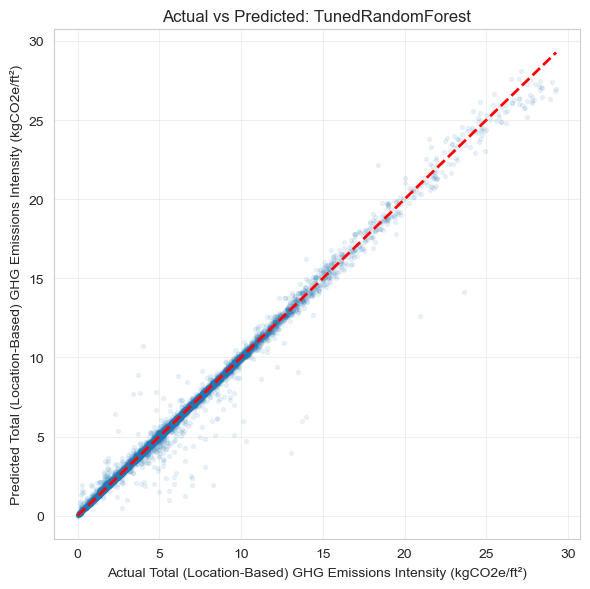

In [20]:
plot_actual_vs_predicted(
    y_test,
    tuned_predictions,
    title="Actual vs Predicted: TunedRandomForest",
)


,Feature,Importance
0,num__Fuel Use Intensity (kBtu/ft²),0.846932
1,num__natural_gas_share,0.052097
2,num__Log Total Fuel Use,0.036300
3,num__electricity_grid_purchase_share,0.035348
4,num__Calendar Year,0.013497
5,cat__Largest Property Use Type_Multifamily Hou...,0.003766
6,num__Model GFA (ft²),0.002631
7,num__Log Model GFA,0.002274
8,num__Largest Use Share of GFA,0.001751
9,cat__Largest Property Use Type_Supermarket/Gro...,0.000864


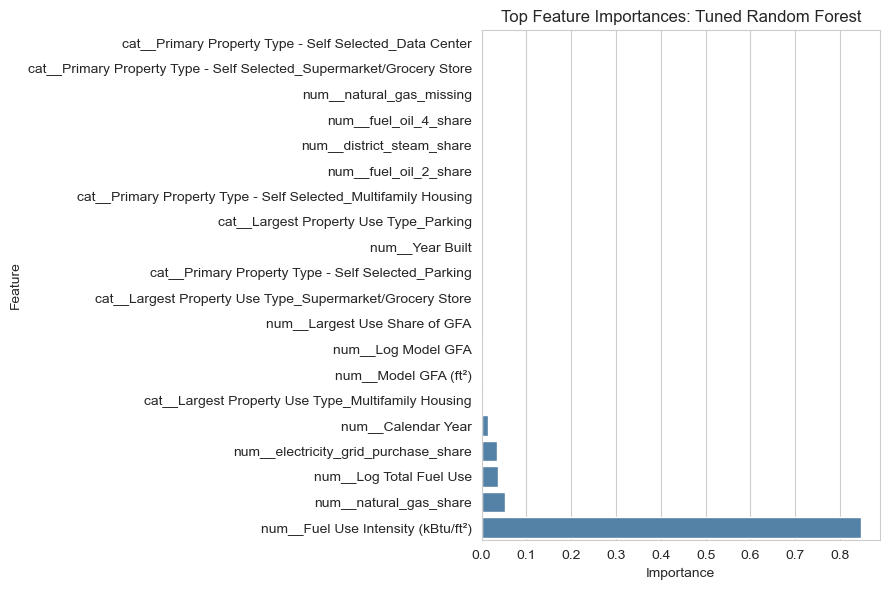

,Feature,Importance
6,num__Fuel Use Intensity (kBtu/ft²),0.846932
10,num__natural_gas_share,0.052097
8,num__Log Total Fuel Use,0.036300
9,num__electricity_grid_purchase_share,0.035348
0,num__Calendar Year,0.013497
144,cat__Largest Property Use Type_Multifamily Hou...,0.003766
4,num__Model GFA (ft²),0.002631
7,num__Log Model GFA,0.002274
5,num__Largest Use Share of GFA,0.001751
179,cat__Largest Property Use Type_Supermarket/Gro...,0.000864


In [21]:
importance_df = summarize_feature_importance(tuned_pipeline)
importance_df.head(20)
